<a href="https://colab.research.google.com/github/pranati-56/Production_RAG/blob/main/Copy_of_production_rag_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Production-Level RAG, From Scratch

A from-scratch implementation of a Retrieval-Augmented Generation pipeline, built to
follow a two-day "Production-Level RAG" workshop. No LangChain / LlamaIndex — every
stage (document parsing, chunking, embedding, retrieval, generation, evaluation) is
implemented by hand so the trade-offs at each stage are visible and tunable.

**Worked example:** a nutrition chatbot grounded in *Human Nutrition: 2020 Edition*
(University of Hawai'i at Mānoa, CC BY 4.0), a ~1,200-page, digitally-born PDF.

**Runtime:** Google Colab. A **T4 GPU** (Runtime → Change runtime type → T4 GPU) speeds
up the local embedding step (§8) but is no longer *required* — every LLM call in this
notebook goes through the Gemini API, not a locally-hosted model.

## Contents
1. Setup
2. Get the source document
3. Document processing (data ingestion) + EDA
4. Chunking strategies, explored from scratch (fixed-size, semantic, structural, recursive, LLM-based via Gemini)
5. Chunking strategy comparison
6. **Testing the chunking functions**
7. Building the production chunk set (sentence-based fixed chunking)
8. Embedding the chunks (CPU vs. GPU vs. batched GPU)
9. Retrieval
10. Generation (via the Gemini API)
11. Assembling the full RAG pipeline
12. Evaluating the pipeline with RAGAS (Gemini as the judge model)
13. Engineer's-choice recap + beyond this notebook (production deployment)

> **Engineer's choice.** At several points there is no single right answer — only a
> trade-off that depends on your data, your client's constraints, and your budget.
> Those points are called out explicitly so you can make the call yourself on a new
> problem, instead of copying a default. This particular notebook makes one deliberate
> simplifying choice throughout: **Gemini is the only LLM used, everywhere** (§4.5
> chunking, §10 generation, §12 evaluation judge) — one API key, entered once. See the
> dependency note in §1 for exactly what that does (and doesn't) still pull in from
> Hugging Face.

> **Documentation convention.** Every function below carries a real docstring
> (parameters, return shape, and behavior at the edges — empty input, oversized input,
> no-match input) in addition to the surrounding markdown explanation. Read the
> docstring for the exact contract; read the markdown for *why* the function is shaped
> that way and *when* to reach for it over the alternatives.


## 1. Setup

**Dependency note — Gemini-only LLM, minimal Hugging Face footprint.** Every LLM call in
this notebook (LLM-based chunking in §4.5, generation in §10, the evaluation judge in
§12) goes through the **Gemini API** — one API key, entered once, reused everywhere. The
only thing this notebook still gets from Hugging Face is downloading two small, **public,
ungated** sentence-embedding models via `sentence-transformers` (`all-MiniLM-L6-v2` in
§4.2, `all-mpnet-base-v2` in §8) — no Hugging Face account, access token, login, or
gated-model license click-through required anywhere. `sentence-transformers` pulls in
the `transformers` package as its own internal implementation detail; that's the
embedding library managing its own dependency, not something this notebook imports or
drives directly.


In [ ]:
!pip install -q PyMuPDF sentence-transformers nltk pandas numpy matplotlib tqdm \
    google-genai langchain-google-genai ragas datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.3/73.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.9/565.9 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.5/252.5 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.7/123.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.9/353.9 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69

In [ ]:
import os
import re
import time
import random
import textwrap
import statistics
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import fitz  # PyMuPDF

import nltk
for _pkg in ("punkt", "punkt_tab"):
    try:
        nltk.download(_pkg, quiet=True)
    except Exception:
        pass

from sentence_transformers import SentenceTransformer, util

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("No GPU detected -- the local embedding step (see section 8) will be "
          "noticeably slower on CPU. Runtime -> Change runtime type -> T4 GPU if you "
          "want to see the CPU/GPU speed comparison there. Every LLM call in this "
          "notebook goes through the Gemini API, so generation itself does not need a GPU.")

Using device: cuda


## 2. Get the source document

We use *Human Nutrition: 2020 Edition* — an open-licensed (CC BY 4.0), ~1,200-page,
**digitally-born** textbook (no scanning artifacts, so no OCR is needed — see the
document-processing engineer's-choice section below for when that assumption breaks).

To use your own PDF instead: upload it in the Colab file browser (left sidebar) and
point `PDF_PATH` at it — everything downstream is unaffected.


In [ ]:
PDF_URL = "https://pressbooks.oer.hawaii.edu/humannutrition2/open/download?type=pdf"
PDF_PATH = Path("human_nutrition_2020.pdf")

if not PDF_PATH.exists():
    import urllib.request
    print("Downloading Human Nutrition: 2020 Edition (~27 MB, CC BY 4.0)...")
    urllib.request.urlretrieve(PDF_URL, PDF_PATH)
    print("Done.")
else:
    print("PDF already present.")

print(f"{PDF_PATH.stat().st_size / 1e6:.1f} MB on disk")

Done.
26.9 MB on disk


## 3. Document processing (data ingestion) + EDA

The most-skipped step in RAG tutorials. Before picking a chunking strategy you need to
know: how much text is on a page, on average, and does that comfortably fit inside the
input limit of the embedding model you plan to use?

**Engineer's choice — document parsing:**

| Tool | Use it when | Trade-off |
|---|---|---|
| **PyMuPDF** (`fitz`) | Text is digitally born (no scans) | Fastest by far (~10-15x faster than Docling); can't read text baked into an image |
| **Tesseract** (OCR) | Scanned pages, handwritten text, photographed documents | Only tool here that can read pixels-as-text |
| **Docling** | Tables, schemas, mixed text+image+table documents | ~50x slower than PyMuPDF; best structure preservation (real rows/columns, JSON/markdown export); can be paired with an OCR backend |

Our PDF is plain digital text with no meaningful tables, so PyMuPDF is the right (and
fastest) choice.


In [ ]:
def text_formatter(text: str) -> str:
    '''Collapse the whitespace/newline noise PDF extraction introduces.

    Parameters
    ----------
    text : str
        Raw text, possibly containing repeated spaces, tabs, and newlines.

    Returns
    -------
    str
        The same text with every run of whitespace collapsed to a single space,
        and leading/trailing whitespace stripped. Returns "" for "" or
        whitespace-only input.
    '''
    return " ".join(text.split())


# Raw PyMuPDF page index 42 is the book's own printed "page 1" (Chapter 1 start) --
# every front-matter page before that gets a negative "page_number" here, which is
# harmless and lets every downstream page_number match the number printed in the book.
PAGE_OFFSET = 41


def open_and_read_pdf(pdf_path: str) -> list[dict]:
    '''Read every page of a PDF into a list of per-page stat dictionaries.

    Parameters
    ----------
    pdf_path : str
        Path to a PDF file readable by PyMuPDF.

    Returns
    -------
    list[dict]
        One dict per page, in page order, with keys:
        page_number (int, aligned to the book's own printed page numbers via
        PAGE_OFFSET), raw_text (str, original line breaks preserved -- needed later
        for paragraph-aware chunking), text (str, whitespace-collapsed via
        text_formatter -- used for word/sentence counts and most chunking),
        page_char_count, page_word_count, page_sentence_count_raw (naive ". "-split
        count), and page_token_count (a ~4-chars-per-token heuristic, not an exact
        tokenizer count).
    '''
    doc = fitz.open(pdf_path)
    pages_and_texts = []
    for i, page in enumerate(tqdm(doc, desc="Reading pages")):
        raw_text = page.get_text()
        clean_text = text_formatter(raw_text)
        pages_and_texts.append({
            "page_number": i - PAGE_OFFSET,
            "raw_text": raw_text,
            "text": clean_text,
            "page_char_count": len(clean_text),
            "page_word_count": len(clean_text.split(" ")),
            "page_sentence_count_raw": len(clean_text.split(". ")),
            "page_token_count": len(clean_text) / 4,
        })
    return pages_and_texts


pages_and_texts = open_and_read_pdf(str(PDF_PATH))
len(pages_and_texts)

Reading pages:   0%|          | 0/1208 [00:00<?, ?it/s]

1208

In [ ]:
random.sample(pages_and_texts, k=2)

[{'page_number': 1120,
  'raw_text': 'An interactive or media element has been \nexcluded from this version of the text. You can \nview it online here: \nhttp://pressbooks.oer.hawaii.edu/\nhumannutrition2/?p=566 \n\xa0\n1120  |  Threats to Health\n',
  'text': 'An interactive or media element has been excluded from this version of the text. You can view it online here: http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=566 1120 | Threats to Health',
  'page_char_count': 191,
  'page_word_count': 27,
  'page_sentence_count_raw': 2,
  'page_token_count': 47.75},
 {'page_number': 617,
  'raw_text': 'Image by \nJames \nHeilman, MD \n/ CC BY-SA \n3.0 \nCalcium inadequacy is most prevalent in adolescent girls and the \nelderly. Proper dietary intake of calcium is critical for proper bone \nhealth. \nDespite the wealth of evidence supporting the many health \nbenefits of calcium (particularly bone health), the average American \ndiet falls short of achieving the recommended dietary intakes 

In [ ]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count
count,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1120.50,171.99,10.52,280.12
std,348.86,551.86,86.44,6.55,137.97
min,-41.00,0.00,1.00,1.00,0.00
25%,260.75,741.50,109.00,5.00,185.38
50%,562.50,1191.50,183.00,10.00,297.88
75%,864.25,1572.25,239.00,15.00,393.06
max,1166.00,2271.00,393.00,39.00,567.75


**Why we care about tokens-per-page:** the sentence-transformer embedding models we'll
use later (`all-mpnet-base-v2`, `all-MiniLM-L6-v2`) silently **truncate any input past
384 word pieces**. If a chunk is longer than that, the tail of it is thrown away before
it ever reaches the model. As long as the *mean + one standard deviation* of your chunk
size sits comfortably under 384, a page-sized (or ~10-sentence-sized) chunk is safe to
embed whole.


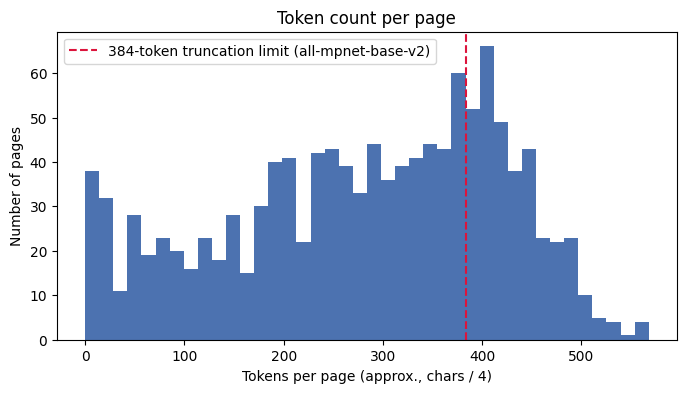

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["page_token_count"], bins=40, color="#4C72B0")
ax.axvline(384, color="crimson", linestyle="--", label="384-token truncation limit (all-mpnet-base-v2)")
ax.set_xlabel("Tokens per page (approx., chars / 4)")
ax.set_ylabel("Number of pages")
ax.set_title("Token count per page")
ax.legend()
plt.show()

In [ ]:
# Sanity check the page-numbering offset: the book's own page 5 should be about macronutrients.
sample = next(p for p in pages_and_texts if p["page_number"] == 5)
print(sample["text"][:300])

Macronutrients Nutrients that are needed in large amounts are called macronutrients. There are three classes of macronutrients: carbohydrates, lipids, and proteins. These can be metabolically processed into cellular energy. The energy from macronutrients comes from their chemical bonds. This chemica


## 4. Chunking strategies, explored from scratch

Chunking is the bridge between "we have a document" and "we can retrieve the bits of it
that are relevant to a question." The quality of everything downstream — retrieval,
generation, grounding — is bounded by how good your chunks are. There is no single best
strategy; each one trades off speed, structure-awareness, and semantic coherence
differently. We implement all five from scratch and compare them empirically below.

**Quick reference** (see §5 and §13 for the full, empirically-grounded version of this table):

| Strategy | Unit it cuts on | Structure-aware? | Semantics-aware? | Relative cost |
|---|---|---|---|---|
| Fixed-size | N characters | No | No | Lowest |
| Semantic | Sentence, grouped by embedding similarity | No | Yes | Medium (one embed call per sentence) |
| Structural | Document's own section/chapter markers | Yes | No | Low (regex only) |
| Recursive | Paragraph → line → sentence, capped at N chars | Yes, with a size ceiling | No | Low |
| LLM-based | Wherever an LLM says the topic shifts | No (data-driven) | Yes | Highest (one LLM call per page) |


### 4.1 Fixed-size chunking

Cut the text every *N* characters, full stop. Fast, but blind to sentence and section
boundaries — a chunk can start or end mid-sentence, which can sever exactly the
information a later query needs.

**Parameters:** `chunk_size` (int, default 500) — target maximum chunk length in
characters; the function never exceeds this, breaking on the nearest space instead of
mid-word.


In [ ]:
def chunk_fixed_size(text: str, chunk_size: int = 500) -> list[str]:
    '''Split text into non-overlapping pieces of at most chunk_size characters.

    Breaks on the nearest preceding space within the window so words are never cut
    in half; falls back to a hard cut at exactly chunk_size only if no space exists
    in that window (e.g. one very long unbroken token).

    Parameters
    ----------
    text : str
        The text to split. "" returns [].
    chunk_size : int, default 500
        Hard upper bound, in characters, on every returned chunk. Must be a
        positive integer -- chunk_size <= 0 will loop forever.

    Returns
    -------
    list[str]
        Non-empty, whitespace-trimmed chunks, each of length <= chunk_size, in
        original order. Concatenating them (with spaces) reproduces the original
        words with none dropped or duplicated.
    '''
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        if end < len(text):
            space = text.rfind(" ", start, end)
            if space > start:
                end = space
        piece = text[start:end].strip()
        if piece:
            chunks.append(piece)
        start = end
    return chunks


fixed_chunks = []
for page in pages_and_texts:
    for chunk in chunk_fixed_size(page["text"], chunk_size=500):
        fixed_chunks.append({"page_number": page["page_number"], "chunk": chunk, "char_count": len(chunk)})

print(f"Total fixed-size chunks: {len(fixed_chunks)}")
random.sample(fixed_chunks, k=2)

Total fixed-size chunks: 3324


[{'page_number': 566,
  'chunk': 'Image by Allison Calabrese / CC BY 4.0 Figure 9.13 Niacin Deficiency, Pellagra 566 | Water-Soluble Vitamins',
  'char_count': 107},
 {'page_number': 791,
  'chunk': 'needed for a pregnancy typically retain that excess weight as body fat. If those few pounds increase a new mother’s BMI by a unit or more, that could lead to complications such as hypertension or Type 2 diabetes in future pregnancies or later in life. pregnancy/during. Published 2012. Accessed November 22, 2017. 5. Stuebe AM, Rich-Edwards JW. (2009). The Reset Hypothesis: Lactation and Maternal Metabolism. , American Journal of Perinatology, 26(1), 81–88. Pregnancy | 791',
  'char_count': 475}]

**When to actually use this:** huge volumes of unstructured, disorganized text
(scraped forum threads, tweets, a pile of books with no consistent internal structure)
where you need a fast baseline and can tolerate some semantic breakage.


### 4.2 Semantic chunking

Grow a chunk sentence by sentence, keeping each new sentence only while it stays
semantically close (cosine similarity above a threshold) to the chunk's **anchor**
sentence — the first sentence in that chunk, not the previous one. The moment a
sentence's similarity to the anchor drops below the threshold, the chunk closes and a
new one starts.

**Parameters:** `threshold` (float in [0, 1], default 0.75) — the cosine-similarity cutoff;
raise it for tighter, more numerous chunks, lower it for looser, larger ones.


In [ ]:
semantic_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)


def chunk_semantic_page(text: str, model: SentenceTransformer, threshold: float = 0.75) -> list[str]:
    '''Group a page's sentences into chunks by similarity to each chunk's anchor sentence.

    Parameters
    ----------
    text : str
        Page (or document) text to sentence-tokenize and chunk.
    model : SentenceTransformer
        Embedding model used to score sentence-to-sentence similarity.
    threshold : float, default 0.75
        Minimum cosine similarity, against the current chunk's anchor (first)
        sentence, required for a sentence to join that chunk. Below this, a new
        chunk starts and the failing sentence becomes its anchor.

    Returns
    -------
    list[str]
        One string per chunk, each the space-joined sentences that belong to it.
        Returns [] for empty/whitespace-only text; returns a single one-sentence
        chunk for single-sentence text.
    '''
    sentences = nltk.sent_tokenize(text)
    if not sentences:
        return []
    embeddings = model.encode(sentences, convert_to_tensor=True, show_progress_bar=False)

    chunks, current_sentences = [], [sentences[0]]
    anchor = embeddings[0]
    for sentence, embedding in zip(sentences[1:], embeddings[1:]):
        similarity = util.cos_sim(anchor, embedding).item()
        if similarity >= threshold:
            current_sentences.append(sentence)
        else:
            chunks.append(" ".join(current_sentences))
            current_sentences = [sentence]
            anchor = embedding
    chunks.append(" ".join(current_sentences))
    return chunks


semantic_chunks = []
for page in tqdm(pages_and_texts, desc="Semantic chunking"):
    for chunk in chunk_semantic_page(page["text"], semantic_model, threshold=0.75):
        if chunk.strip():
            semantic_chunks.append({"page_number": page["page_number"], "chunk": chunk, "char_count": len(chunk)})

print(f"Total semantic chunks: {len(semantic_chunks)}")
random.sample(semantic_chunks, k=2)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Semantic chunking:   0%|          | 0/1208 [00:00<?, ?it/s]

Total semantic chunks: 12044


[{'page_number': 521,
  'chunk': 'Retinol is the form of vitamin A found in animal-derived foods, and is converted in the body to the biologically active forms of vitamin A: retinal and retinoic acid (thus retinol is sometimes referred to as “preformed vitamin A”).',
  'char_count': 231},
 {'page_number': 1053,
  'chunk': 'Raw and cooked vegetables comprise about 30 percent of the diet and include kale, cabbage, collards, bok choy, and broccoli on a daily 8.',
  'char_count': 137}]

**When to actually use this:** transcripts and unstructured streams-of-ideas where
topic integrity matters more than speed — parliamentary debate transcripts, lecture
transcripts without timestamps, meeting notes. Expect a large number of small chunks on
a document like a textbook, where the topic changes almost every paragraph — that's a
real limitation, not a bug (see the comparison in §5).


### 4.3 Recursive chunking

The "best of both worlds" strategy. Try splitting on the coarsest separator first
(double newline ≈ paragraph break); if a resulting piece is still over the max size,
recursively split *that piece* using the next, finer separator (single newline, then
sentence-ish breaks). Pieces already under the max size are left alone. This respects
document structure while guaranteeing no chunk blows past your size budget — unlike
structural chunking below.

This needs the *original* line breaks, so it operates on `raw_text`, not the
whitespace-collapsed `text` used above.

**Parameters:** `max_chars` (int, default 1000) — hard ceiling on chunk size, in
characters. `separators` (tuple of str, default `("\n\n", "\n", ". ")`) — tried in
order, coarsest first; a piece that isn't split by the current separator falls through
to the next one.


In [ ]:
def chunk_recursive(text: str, max_chars: int = 1000, separators=("\n\n", "\n", ". ")) -> list[str]:
    '''Recursively split text on progressively finer separators, capped at max_chars.

    Parameters
    ----------
    text : str
        Text to split. Should retain original line breaks for the "\n\n"/"\n"
        separators to mean anything (pass raw_text, not a whitespace-collapsed
        version).
    max_chars : int, default 1000
        A piece at or under this length is left as its own chunk without further
        splitting, regardless of which separator produced it.
    separators : tuple[str, ...], default ("\\n\\n", "\\n", ". ")
        Tried in order, coarsest first. If a separator doesn't actually split a
        piece (it isn't present), that piece is retried with the remaining,
        finer separators.

    Returns
    -------
    list[str]
        Chunks in original order. If a piece is still over max_chars after every
        separator is exhausted (no separator of any kind found inside it), it is
        returned whole rather than silently dropped or truncated.
    '''
    if len(text) <= max_chars or not separators:
        return [text] if text.strip() else []

    sep, remaining_separators = separators[0], separators[1:]
    pieces = [p for p in text.split(sep) if p.strip()]

    if len(pieces) == 1:
        # This separator didn't actually split anything -- try the next, finer one.
        return chunk_recursive(text, max_chars, remaining_separators)

    chunks = []
    for piece in pieces:
        chunks.extend(chunk_recursive(piece, max_chars, remaining_separators))
    return chunks


recursive_chunks = []
for page in pages_and_texts:
    for chunk in chunk_recursive(page["raw_text"], max_chars=1000):
        cleaned = text_formatter(chunk)
        if cleaned:
            recursive_chunks.append({"page_number": page["page_number"], "chunk": cleaned, "char_count": len(cleaned)})

print(f"Total recursive chunks: {len(recursive_chunks)}")
random.sample(recursive_chunks, k=2)

Total recursive chunks: 25414


[{'page_number': 832,
  'chunk': 'One of the first challenges nursing mothers face is learning how',
  'char_count': 64},
 {'page_number': 601,
  'chunk': 'cancer risks, and lower blood',
  'char_count': 29}]

**When to actually use this:** the safe default whenever a document has *some*
structure but section sizes vary a lot (research papers, reports) — you get structural
chunks where sections are short, and automatic further splitting where one section runs
long.


### 4.4 Structural chunking

The most intuitive strategy when a document has a genuinely regular structure: split
exactly at section/chapter boundaries. This book conveniently repeats a running header
— `"University of Hawai'i at Mānoa Food Science and Human Nutrition Program"` — at the
start of most new chapters and sections, so we can use that as a chapter marker via
regex. **This exact trick is document-specific** — a different client's document will
need a different marker (font-size cues, a table of contents with page numbers, digital
section tags, etc.). The technique — find *some* reliable, repeating structural
signal and split on it — is what generalizes, not the regex itself.

**Parameters:** `marker` (compiled `re.Pattern`) — matched against the concatenated
document text; every match starts a new chunk. If the marker never matches at all, the
whole document is returned as a single chunk (see §6 for the test that pins this edge
case down — a subtle version of it was broken until it was tested).


In [ ]:
# Restrict to the book's actual body (skip the front matter / author bios, where this
# same header text repeats far more densely and would over-fragment the output).
body_pages = [p for p in pages_and_texts if p["page_number"] >= 1]

# \s+ tolerates the newline this header wraps across on the page; wildcards absorb the
# apostrophe/macron glyphs (', a-macron) that vary in encoding across the PDF.
CHAPTER_MARKER = re.compile(
    r"UNIVERSITY\s+OF\s+HAWAI.{0,3}I\s+AT\s+M.{1,2}NOA\s+FOOD\s+SCIENCE\s+AND\s+HUMAN\s+NUTRITION\s+PROGRAM",
    re.IGNORECASE,
)


def chunk_structural(pages: list[dict], marker: re.Pattern) -> list[dict]:
    '''Split concatenated page text into one chunk per occurrence of a marker regex.

    Parameters
    ----------
    pages : list[dict]
        Page dicts as produced by open_and_read_pdf -- each needs "page_number"
        and "raw_text".
    marker : re.Pattern
        Compiled regex; every match position becomes a chunk boundary.

    Returns
    -------
    list[dict]
        One dict per chunk, each with "page_number" (the page the chunk starts
        on), "chunk" (whitespace-collapsed text), and "char_count". If marker
        never matches anywhere, returns a single chunk covering the entire input
        rather than an empty list -- the no-match case is a real edge case a
        naive boundary-list implementation can silently get wrong (see §6).
    '''
    doc_text = ""
    page_offsets = []  # (char_offset_into_doc_text, page_number)
    for page in pages:
        page_offsets.append((len(doc_text), page["page_number"]))
        doc_text += page["raw_text"]

    boundaries = [m.start() for m in marker.finditer(doc_text)]
    # Always anchor the boundary list at 0 -- both when there are zero matches
    # (whole document becomes one chunk) and when the first match isn't at 0
    # (the text before it becomes its own leading chunk).
    if not boundaries or boundaries[0] != 0:
        boundaries = [0] + boundaries
    boundaries.append(len(doc_text))

    def page_at(offset):
        page_num = page_offsets[0][1]
        for start, num in page_offsets:
            if start <= offset:
                page_num = num
            else:
                break
        return page_num

    chunks = []
    for start, end in zip(boundaries[:-1], boundaries[1:]):
        cleaned = text_formatter(doc_text[start:end])
        if cleaned:
            chunks.append({"page_number": page_at(start), "chunk": cleaned, "char_count": len(cleaned)})
    return chunks


structural_chunks = chunk_structural(body_pages, CHAPTER_MARKER)
print(f"Total structural chunks: {len(structural_chunks)}")
for c in structural_chunks[:3]:
    print(f"page {c['page_number']:>4} | {c['char_count']:>6} chars | {c['chunk'][:80]}")

Total structural chunks: 132
page    1 |    134 chars | PART I CHAPTER 1. BASIC CONCEPTS IN NUTRITION Chapter 1. Basic Concepts in Nutri
page    3 |  12958 chars | UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN NUTRITION PROGRAM AND HUMA
page   14 |   2461 chars | UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN NUTRITION PROGRAM AND HUMA


**When to actually use this:** legal codes (articles/sections), earnings-call
transcripts with clear speaker/topic headers, medical records with fixed fields (chief
complaint, history, assessment, plan) — anywhere the document format itself is the
client's true schema. **The catch:** one oversized section becomes one oversized chunk,
which can blow the context budget right back open — the same problem RAG exists to
solve. That's exactly the gap recursive chunking closes.


### 4.5 LLM-based chunking

When there's no structure *and* no clean semantic drift to exploit — e.g. a chat
transcript that jumps between booking a test drive, comparing prices, and picking a
delivery date — hand the splitting decision to an LLM directly: ask it to insert a
delimiter at every point the topic shifts.

This uses **Gemini** — the one API key entered below is reused for generation (§10) and
the evaluation judge (§12) too, so you only enter it once per session. Model IDs move
fast; check
[ai.google.dev/gemini-api/docs/models](https://ai.google.dev/gemini-api/docs/models)
for the current fast/general-purpose tier and update `GEMINI_MODEL` if `gemini-3.6-flash`
has since been superseded (Gemini model names churn fast — `gemini-2.0-flash`, the
obvious default as recently as mid-2026, was fully retired by June 2026). The
prompt-building and delimiter-splitting
logic (`build_llm_chunk_prompt` / `split_on_llm_delimiter`, tested standalone in §6) is
provider-agnostic by design — swapping to a different chat-completion API later is a
matter of changing the one function that calls it, not the logic around it.

This is the most expensive chunking strategy by roughly two orders of magnitude, so we
run it on a small **sample** of pages only, not the whole 1,200-page book, and
extrapolate the cost.


In [ ]:
import getpass
from google import genai as google_genai
from google.genai import types as genai_types

GEMINI_MODEL = "gemini-3.1-flash-lite"  # check ai.google.dev/gemini-api/docs/models -- verified current as of Aug 2026

gemini_api_key = getpass.getpass("Gemini API key (used only in this session, never stored): ")
gemini_client = google_genai.Client(api_key=gemini_api_key)

Gemini API key (used only in this session, never stored): ··········


In [ ]:
LLM_CHUNK_DELIMITER = "<<<SPLIT>>>"


def build_llm_chunk_prompt(text: str, delimiter: str = LLM_CHUNK_DELIMITER) -> str:
    '''Build the instruction sent to the LLM for LLM-based chunking.

    Parameters
    ----------
    text : str
        The text to be chunked by the LLM.
    delimiter : str, default LLM_CHUNK_DELIMITER
        The literal marker the LLM is asked to insert at topic-shift boundaries.

    Returns
    -------
    str
        The full prompt, ready to send to any chat-completion-style API -- kept
        provider-agnostic on purpose, see split_on_llm_delimiter.
    '''
    return (
        f"Insert the delimiter {delimiter} at each point in the following text where the "
        "topic or context shifts to something new. Do not change, summarize, or remove "
        "any of the original text -- only insert the delimiter.\n\nTEXT:\n" + text
    )


def split_on_llm_delimiter(marked_text: str, delimiter: str = LLM_CHUNK_DELIMITER) -> list[str]:
    '''Pure helper: split LLM-marked text on its own delimiter. No API call -- fully unit-testable.

    Parameters
    ----------
    marked_text : str
        Text already containing zero or more literal delimiter markers, as
        returned by an LLM that was asked to insert them.
    delimiter : str, default LLM_CHUNK_DELIMITER
        The exact marker string to split on.

    Returns
    -------
    list[str]
        Non-empty, whitespace-trimmed pieces, in order. Empty pieces (e.g. from a
        delimiter at the very start/end, or two delimiters in a row) are dropped.
        Text with no delimiter at all comes back as a single-element list.
    '''
    return [c.strip() for c in marked_text.split(delimiter) if c.strip()]


def chunk_llm_based(text: str, model: str = GEMINI_MODEL) -> list[str]:
    '''LLM-based chunking via Gemini. See build_llm_chunk_prompt / split_on_llm_delimiter.

    Parameters
    ----------
    text : str
        Text to chunk.
    model : str, default GEMINI_MODEL
        Gemini model id.

    Returns
    -------
    list[str]
        Chunks as produced by split_on_llm_delimiter on the model's response.
    '''
    response = gemini_client.models.generate_content(
        model=model,
        contents=build_llm_chunk_prompt(text),
        config=genai_types.GenerateContentConfig(temperature=0),
    )
    return split_on_llm_delimiter(response.text or "")


SAMPLE_SIZE = 5  # keep this small -- see the timing print below for why
sample_pages = random.sample(body_pages, SAMPLE_SIZE)

llm_chunks = []
start_time = time.time()
for page in tqdm(sample_pages, desc="LLM-based chunking (sample, Gemini)"):
    for chunk in chunk_llm_based(page["text"]):
        llm_chunks.append({"page_number": page["page_number"], "chunk": chunk, "char_count": len(chunk)})
elapsed = time.time() - start_time

projected_minutes = elapsed / SAMPLE_SIZE * len(pages_and_texts) / 60
print(f"{SAMPLE_SIZE} pages took {elapsed:.1f}s -> the full {len(pages_and_texts)}-page book "
      f"would take roughly {projected_minutes:.0f} min, at real API cost, for this alone.")

LLM-based chunking (sample, Gemini):   0%|          | 0/5 [00:00<?, ?it/s]

5 pages took 6.9s -> the full 1208-page book would take roughly 28 min, at real API cost, for this alone.


**When to actually use this:** small, high-value, context-drifting corpora only —
voice-assistant conversation logs, customer-support chat transcripts. Never the default
for a large static document; the cost and latency don't justify it, and the output is
stochastic (rerun the same document and you can get different splits).


## 5. Chunking strategy comparison

Before running anything through an LLM, a purely statistical comparison already tells
you a lot: how many chunks did each strategy produce, how big are they on average, and
how much does that size vary?


In [ ]:
strategy_chunks = {
    "Fixed-size": fixed_chunks,
    "Semantic": semantic_chunks,
    "Recursive": recursive_chunks,
    "Structural": structural_chunks,
    "LLM-based (sample)": llm_chunks,
}

summary_rows = []
for name, chunks in strategy_chunks.items():
    sizes = [c["char_count"] for c in chunks]
    summary_rows.append({
        "strategy": name,
        "num_chunks": len(chunks),
        "avg_chars": round(statistics.mean(sizes), 1) if sizes else 0,
        "std_chars": round(statistics.pstdev(sizes), 1) if len(sizes) > 1 else 0,
        "min_chars": min(sizes) if sizes else 0,
        "max_chars": max(sizes) if sizes else 0,
    })

comparison_df = pd.DataFrame(summary_rows).set_index("strategy")
comparison_df

,num_chunks,avg_chars,std_chars,min_chars,max_chars
strategy,,,,,
Fixed-size,3324,406.6,146.0,4,499
Semantic,12044,111.5,99.4,1,1635
Recursive,25414,52.3,78.3,1,978
Structural,132,10048.2,8584.7,134,57762
LLM-based (sample),20,263.1,183.8,13,678


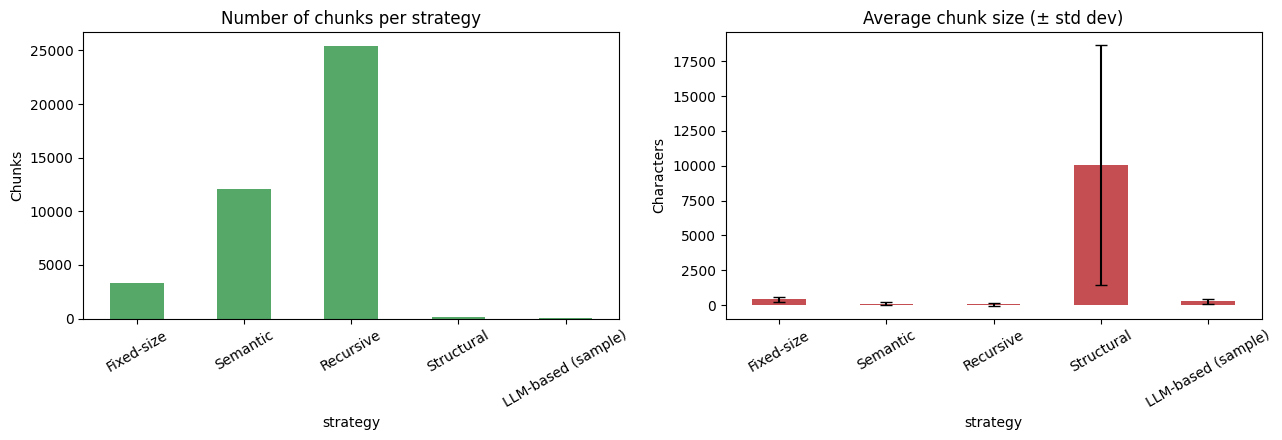

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

comparison_df["num_chunks"].plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].set_title("Number of chunks per strategy")
axes[0].set_ylabel("Chunks")
axes[0].tick_params(axis="x", rotation=30)

comparison_df["avg_chars"].plot(kind="bar", ax=axes[1], yerr=comparison_df["std_chars"], color="#C44E52", capsize=4)
axes[1].set_title("Average chunk size (± std dev)")
axes[1].set_ylabel("Characters")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

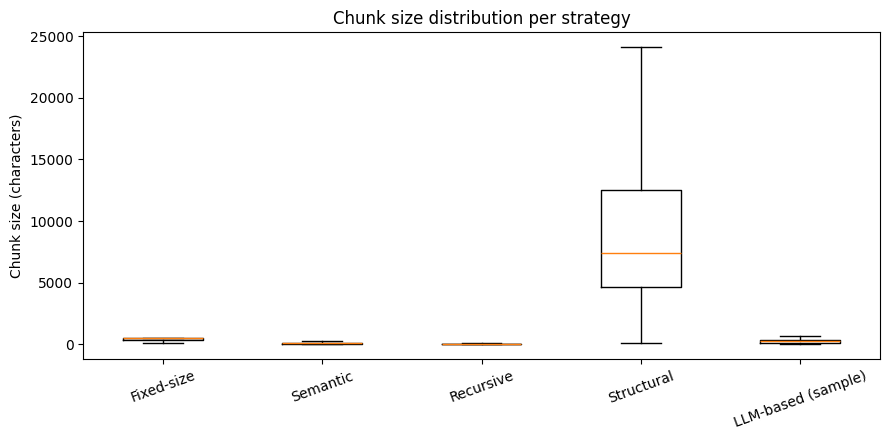

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
box_data = [[c["char_count"] for c in chunks] for chunks in strategy_chunks.values()]
ax.boxplot(box_data, tick_labels=list(strategy_chunks.keys()), showfliers=False)
ax.set_ylabel("Chunk size (characters)")
ax.set_title("Chunk size distribution per strategy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Reading this table (LLM-based numbers here are a small-sample estimate, not a full
run — see §4.5):**

- **Fixed-size** — most chunks, tightly consistent size, essentially zero variance. Fast, dumb.
- **Semantic** — the most chunks of all, and small ones — on a textbook, the topic drifts
  almost every paragraph, so the anchor-similarity threshold keeps closing chunks early.
  Preserves meaning within a chunk, at the cost of very short, fragmented context.
- **Structural** — the fewest chunks, by far the largest average size, and by far the
  highest variance — some chapters are short, some are long, and structural chunking
  just accepts that. Great for capturing whole sections; risky for LLM context budgets.
- **Recursive** — sits in the moderate middle on every axis: this is the "safe default"
  signature — structure-aware, but with a hard ceiling on size.
- **LLM-based** — usually lands in a reasonable, human-judged middle ground on size, at
  a cost and latency that rules it out for large static corpora.

This statistical view is a fast first filter, not the final answer — the real test is
running each strategy through the full pipeline and comparing retrieval/generation
quality (§12).


## 6. Testing the chunking functions

"It ran without an error" is not the same as "it's correct" — a chunking bug can
silently drop text, produce empty chunks, or blow past a size budget without ever
raising an exception. Before trusting any of the five strategies above on a real
document, we pin down their actual behavior with small, fast, synthetic test cases —
no dependency on the real 1,200-page PDF, so these run in well under a second.

Each test is a plain function using `assert`; a tiny runner below collects and reports
pass/fail so this works standalone in a notebook without pulling in `pytest`. (If you
prefer real `pytest` discovery, `pip install ipytest` and wrap these same functions with
`ipytest.run()` instead — the test bodies don't need to change.)

**These tests already caught a real bug**: the first version of `chunk_structural`
silently returned **zero chunks** — the entire document, discarded — whenever its marker
regex matched nowhere in the text. That path never fired against the real book (the
marker always matched dozens of times), so it stayed invisible until a test exercised it
directly. The fixed version above already has the correction; the test for it is
included so a future edit can't reintroduce the bug unnoticed.


In [ ]:
def run_tests(tests: dict) -> None:
    '''Run a {name: test_fn} dict, printing PASS/FAIL/ERROR per test plus a summary.

    Parameters
    ----------
    tests : dict[str, Callable[[], None]]
        Each value is called with no arguments; it should raise AssertionError
        (typically via a bare `assert`) to signal failure, or return normally to
        signal success.
    '''
    passed, failed = 0, []
    for name, test_fn in tests.items():
        try:
            test_fn()
            passed += 1
            print(f"PASS   {name}")
        except AssertionError as e:
            failed.append(name)
            print(f"FAIL   {name}: {e}")
        except Exception as e:
            failed.append(name)
            print(f"ERROR  {name}: {type(e).__name__}: {e}")
    print(f"\n{passed}/{len(tests)} passed" + (f" -- failed: {failed}" if failed else " -- all green"))

### 6.1 `text_formatter`

In [ ]:
def test_text_formatter_collapses_whitespace():
    assert text_formatter("a   b\n\nc\td") == "a b c d"

def test_text_formatter_empty_string():
    assert text_formatter("") == ""

def test_text_formatter_strips_ends():
    assert text_formatter("   leading and trailing   ") == "leading and trailing"

run_tests({
    "text_formatter/collapses_whitespace": test_text_formatter_collapses_whitespace,
    "text_formatter/empty_string": test_text_formatter_empty_string,
    "text_formatter/strips_ends": test_text_formatter_strips_ends,
})

PASS   text_formatter/collapses_whitespace
PASS   text_formatter/empty_string
PASS   text_formatter/strips_ends

3/3 passed -- all green


### 6.2 `chunk_fixed_size`

In [ ]:
def test_fixed_size_empty_text_returns_no_chunks():
    assert chunk_fixed_size("", chunk_size=100) == []

def test_fixed_size_short_text_is_one_chunk():
    text = "A short sentence under the limit."
    assert chunk_fixed_size(text, chunk_size=100) == [text]

def test_fixed_size_respects_budget():
    text = ("word " * 400).strip()  # ~2000 chars, spaces every 5 chars
    chunks = chunk_fixed_size(text, chunk_size=100)
    assert all(len(c) <= 100 for c in chunks), "a chunk exceeded its size budget"

def test_fixed_size_never_splits_a_word_and_preserves_content():
    text = ("word " * 400).strip()
    chunks = chunk_fixed_size(text, chunk_size=100)
    for c in chunks:
        assert not c.startswith(" ") and not c.endswith(" ")
    rebuilt_words = " ".join(chunks).split()
    assert rebuilt_words == text.split(), "chunking changed, dropped, or duplicated words"

run_tests({
    "fixed_size/empty_text": test_fixed_size_empty_text_returns_no_chunks,
    "fixed_size/short_text_single_chunk": test_fixed_size_short_text_is_one_chunk,
    "fixed_size/respects_budget": test_fixed_size_respects_budget,
    "fixed_size/never_splits_word_preserves_content": test_fixed_size_never_splits_a_word_and_preserves_content,
})

PASS   fixed_size/empty_text
PASS   fixed_size/short_text_single_chunk
PASS   fixed_size/respects_budget
PASS   fixed_size/never_splits_word_preserves_content

4/4 passed -- all green


### 6.3 `chunk_semantic_page`

These reuse the real `semantic_model` loaded in §4.2 rather than a mock, so the
assertions are on genuine embedding behavior, not a stand-in. The similarity margins
are picked wide enough (near-paraphrase vs. two unrelated domains) to be robust to minor
model-version differences.


In [ ]:
def test_semantic_chunking_empty_text():
    assert chunk_semantic_page("", semantic_model) == []

def test_semantic_chunking_single_sentence():
    text = "This is one sentence."
    assert chunk_semantic_page(text, semantic_model) == [text]

def test_semantic_chunking_similar_sentences_stay_together():
    text = "The cat sat on the mat. A cat was sitting on the mat."
    chunks = chunk_semantic_page(text, semantic_model, threshold=0.5)
    assert len(chunks) == 1, "a near-paraphrase should stay in the same chunk at a modest threshold"

def test_semantic_chunking_dissimilar_sentences_split():
    text = "The cat sat on the mat. Quantum computers use qubits to perform calculations."
    chunks = chunk_semantic_page(text, semantic_model, threshold=0.9)
    assert len(chunks) == 2, "two unrelated-topic sentences should split at a high threshold"

run_tests({
    "semantic/empty_text": test_semantic_chunking_empty_text,
    "semantic/single_sentence": test_semantic_chunking_single_sentence,
    "semantic/similar_sentences_merge": test_semantic_chunking_similar_sentences_stay_together,
    "semantic/dissimilar_sentences_split": test_semantic_chunking_dissimilar_sentences_split,
})

PASS   semantic/empty_text
PASS   semantic/single_sentence
PASS   semantic/similar_sentences_merge
PASS   semantic/dissimilar_sentences_split

4/4 passed -- all green


### 6.4 `chunk_recursive`

In [ ]:
def test_recursive_short_text_untouched():
    text = "Short paragraph, no splitting needed."
    assert chunk_recursive(text, max_chars=1000) == [text]

def test_recursive_splits_on_paragraph_breaks():
    text = "First paragraph here.\n\nSecond paragraph here.\n\nThird paragraph here."
    chunks = chunk_recursive(text, max_chars=30)
    assert len(chunks) == 3
    assert all(len(c) <= 30 for c in chunks)

def test_recursive_falls_back_through_separators():
    # No blank-line paragraphs at all, but single newlines exist -- should fall back to them.
    text = "Line one is here.\nLine two is here.\nLine three is here."
    chunks = chunk_recursive(text, max_chars=25)
    assert len(chunks) >= 2

def test_recursive_never_drops_a_separatorless_oversized_piece():
    # A single unbroken run with no separators at all -- must still come back whole,
    # not silently dropped, even though it exceeds max_chars.
    text = "a" * 50
    chunks = chunk_recursive(text, max_chars=10, separators=("\n\n", "\n"))
    assert chunks == [text]

run_tests({
    "recursive/short_text_untouched": test_recursive_short_text_untouched,
    "recursive/splits_on_paragraphs": test_recursive_splits_on_paragraph_breaks,
    "recursive/falls_back_to_finer_separator": test_recursive_falls_back_through_separators,
    "recursive/never_drops_oversized_piece": test_recursive_never_drops_a_separatorless_oversized_piece,
})

PASS   recursive/short_text_untouched
PASS   recursive/splits_on_paragraphs
PASS   recursive/falls_back_to_finer_separator
PASS   recursive/never_drops_oversized_piece

4/4 passed -- all green


### 6.5 `chunk_structural`

Uses a tiny synthetic marker (`===CHAPTER===`) and a 4-page fixture instead of the real
book, so this runs instantly and is independent of the real regex. The second test is
the one that failed before the fix described at the top of §6.


In [ ]:
def test_structural_splits_at_marker():
    marker = re.compile(r"===CHAPTER===")
    pages = [
        {"page_number": 1, "raw_text": "Intro text before any marker. "},
        {"page_number": 2, "raw_text": "===CHAPTER=== Chapter one body text. "},
        {"page_number": 3, "raw_text": "More chapter one text. "},
        {"page_number": 4, "raw_text": "===CHAPTER=== Chapter two body text."},
    ]
    chunks = chunk_structural(pages, marker)
    assert len(chunks) == 3, "expected: front matter + chapter one + chapter two"
    assert chunks[0]["page_number"] == 1
    assert chunks[1]["page_number"] == 2
    assert chunks[2]["page_number"] == 4
    assert "Chapter one" in chunks[1]["chunk"]
    assert "Chapter two" in chunks[2]["chunk"]

def test_structural_no_marker_present_is_one_chunk():
    marker = re.compile(r"===CHAPTER===")
    pages = [{"page_number": 1, "raw_text": "Just plain text, no markers anywhere."}]
    chunks = chunk_structural(pages, marker)
    assert len(chunks) == 1, "a document with no marker match must come back as one chunk, not zero"
    assert chunks[0]["page_number"] == 1
    assert "no markers anywhere" in chunks[0]["chunk"]

run_tests({
    "structural/splits_at_marker": test_structural_splits_at_marker,
    "structural/no_marker_is_one_chunk_not_zero": test_structural_no_marker_present_is_one_chunk,
})

ERROR  structural/splits_at_marker: NameError: name 'chunk_structural' is not defined
ERROR  structural/no_marker_is_one_chunk_not_zero: NameError: name 'chunk_structural' is not defined

0/2 passed -- failed: ['structural/splits_at_marker', 'structural/no_marker_is_one_chunk_not_zero']


### 6.6 `split_on_llm_delimiter`

The LLM call itself (§4.5) isn't unit-tested here on purpose — it costs money, needs
network access, and its output is provider-dependent. What *is* fully deterministic and
free to test is the splitting logic that runs on the LLM's output, which is why that
logic was pulled out into its own pure function.


In [ ]:
def test_llm_delimiter_split_basic():
    marked = "First idea here.<<<SPLIT>>>Second idea here.<<<SPLIT>>>Third idea here."
    assert split_on_llm_delimiter(marked) == ["First idea here.", "Second idea here.", "Third idea here."]

def test_llm_delimiter_split_no_delimiter_present():
    marked = "Just one blob of text with no split marker."
    assert split_on_llm_delimiter(marked) == [marked]

def test_llm_delimiter_split_ignores_empty_pieces():
    marked = "<<<SPLIT>>>Only one real piece<<<SPLIT>>><<<SPLIT>>>"
    assert split_on_llm_delimiter(marked) == ["Only one real piece"]

run_tests({
    "llm_chunking/delimiter_split_basic": test_llm_delimiter_split_basic,
    "llm_chunking/no_delimiter_present": test_llm_delimiter_split_no_delimiter_present,
    "llm_chunking/ignores_empty_pieces": test_llm_delimiter_split_ignores_empty_pieces,
})

ERROR  llm_chunking/delimiter_split_basic: NameError: name 'split_on_llm_delimiter' is not defined
ERROR  llm_chunking/no_delimiter_present: NameError: name 'split_on_llm_delimiter' is not defined
ERROR  llm_chunking/ignores_empty_pieces: NameError: name 'split_on_llm_delimiter' is not defined

0/3 passed -- failed: ['llm_chunking/delimiter_split_basic', 'llm_chunking/no_delimiter_present', 'llm_chunking/ignores_empty_pieces']


## 7. Building the production chunk set

For the pipeline we actually assemble below (embedding → retrieval → generation), we
switch to a simple, fast **fixed-size chunking measured in sentences** instead of
characters: group every 10 sentences into one chunk. This is still "fixed-size"
chunking in spirit — no semantics, no structure — just bucketed at a unit (sentences)
that happens to line up conveniently with page length in this book (see the EDA above:
~10 sentences/page, ~287 tokens/page, both comfortably under the 384-token embedding
limit).


In [ ]:
for page in tqdm(pages_and_texts, desc="Sentence-tokenizing pages"):
    page["sentences"] = nltk.sent_tokenize(page["text"])
    page["page_sentence_count"] = len(page["sentences"])

df = pd.DataFrame(pages_and_texts)
df["page_sentence_count"].describe().round(2)

Sentence-tokenizing pages:   0%|          | 0/1208 [00:00<?, ?it/s]

,page_sentence_count
count,1208.00
mean,10.29
std,6.28
min,0.00
25%,5.00
50%,10.00
75%,15.00
max,28.00


In [ ]:
NUM_SENTENCE_CHUNK_SIZE = 10


def split_into_groups(input_list: list, slice_size: int = NUM_SENTENCE_CHUNK_SIZE) -> list[list]:
    '''Slice a list into consecutive groups of at most slice_size items.

    Parameters
    ----------
    input_list : list
        Items to group, in order.
    slice_size : int, default NUM_SENTENCE_CHUNK_SIZE
        Maximum items per group. The final group holds the remainder and may be
        shorter.

    Returns
    -------
    list[list]
        [] for an empty input_list; otherwise ceil(len(input_list) / slice_size)
        groups, each a list, covering every item exactly once in original order.
    '''
    return [input_list[i:i + slice_size] for i in range(0, len(input_list), slice_size)]


def test_split_into_groups_exact_multiple():
    assert split_into_groups(list(range(10)), slice_size=5) == [[0, 1, 2, 3, 4], [5, 6, 7, 8, 9]]

def test_split_into_groups_remainder():
    assert split_into_groups(list(range(7)), slice_size=3) == [[0, 1, 2], [3, 4, 5], [6]]

def test_split_into_groups_empty_list():
    assert split_into_groups([], slice_size=5) == []

run_tests({
    "split_into_groups/exact_multiple": test_split_into_groups_exact_multiple,
    "split_into_groups/remainder": test_split_into_groups_remainder,
    "split_into_groups/empty_list": test_split_into_groups_empty_list,
})

PASS   split_into_groups/exact_multiple
PASS   split_into_groups/remainder
PASS   split_into_groups/empty_list

3/3 passed -- all green


In [ ]:
for page in pages_and_texts:
    page["sentence_chunks"] = split_into_groups(page["sentences"], NUM_SENTENCE_CHUNK_SIZE)

pages_and_chunks = []
for page in pages_and_texts:
    for sentence_chunk in page["sentence_chunks"]:
        joined = " ".join(sentence_chunk).strip()
        joined = re.sub(r"\s+", " ", joined)
        if not joined:
            continue
        pages_and_chunks.append({
            "page_number": page["page_number"],
            "sentence_chunk": joined,
            "chunk_char_count": len(joined),
            "chunk_word_count": len(joined.split(" ")),
            "chunk_token_count": len(joined) / 4,
        })

print(f"Total production chunks: {len(pages_and_chunks)}")
df_chunks = pd.DataFrame(pages_and_chunks)
df_chunks.describe().round(2)

Total production chunks: 1840


,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,1840.00,1840.00,1840.00,1840.00
mean,585.33,735.27,112.90,183.82
std,347.49,449.40,71.51,112.35
min,-41.00,12.00,3.00,3.00
25%,283.00,315.00,45.00,78.75
50%,589.50,745.00,114.00,186.25
75%,891.00,1119.25,173.00,279.81
max,1166.00,1842.00,299.00,460.50


A handful of chunks will have a very low token count — footnotes, page-end
fragments, remnants of figure captions. These carry little retrievable signal, so we
drop anything under a minimum token threshold.


In [ ]:
MIN_TOKEN_LENGTH = 30
pages_and_chunks_over_min = [c for c in pages_and_chunks if c["chunk_token_count"] > MIN_TOKEN_LENGTH]

print(f"Dropped {len(pages_and_chunks) - len(pages_and_chunks_over_min)} chunks "
      f"under {MIN_TOKEN_LENGTH} tokens; {len(pages_and_chunks_over_min)} remain.")
random.sample(pages_and_chunks_over_min, k=2)

Dropped 168 chunks under 30 tokens; 1672 remain.


[{'page_number': 107,
  'sentence_chunk': 'To see how the rise in obesity in this country is paralleled by the rise in Type 2 diabetes, review this report by the CDC. https://www.cdc.gov/diabetes/statistics/slides/ maps_diabetesobesity_trends.pdf What is the causal relationship between overnutrition and Type 2 diabetes? The prevailing theory is that the overconsumption of high-fat and high-sugar foods causes changes in muscle, fat, and liver cells that leads to a diminished response from the pancreatic hormone insulin. These cells are called “insulin-resistant.” Insulin is released after a meal and instructs the liver and other tissues to take up glucose and fatty acids that are circulating in the blood. When cells are resistant to insulin they do not take up enough glucose and fatty acids, so glucose and fatty acids remain at high concentrations in the blood. The chronic elevation of glucose and fatty acids in the blood also causes damage to other tissues over time, so that people who

## 8. Embedding the chunks

Converting each chunk into a vector is where GPU vs. CPU stops being an academic
question. We benchmark three approaches on a sample, then run the fast one on the full
chunk set for real, and save the result to disk.

**Engineer's choice — embedding model:** consider input-token capacity, output vector
size, raw model quality, and open- vs. closed-source, together:

| Model | Type | Notes |
|---|---|---|
| `all-MiniLM-L6-v2` | open-source | 384-dim, small, fast — good for a cheap first pass (used above for semantic chunking) |
| `all-mpnet-base-v2` | open-source | 768-dim, still fully local, better quality — what we use for the production embeddings |
| `text-embedding-3-small/large` | closed-source (OpenAI) | strong quality, per-token cost, no infra to run |
| Qwen / Gemini embedding models | either | check the [MTEB leaderboard](https://huggingface.co/spaces/mteb/leaderboard) for current state-of-the-art, especially for code or numeric-heavy text |

If privacy or cost rules out an API call, stay open-source and local — which is what we
do here.


In [ ]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")

sample_texts = [c["sentence_chunk"] for c in pages_and_chunks_over_min[:200]]

# 1) CPU, one chunk at a time
embedding_model.to("cpu")
start_time = time.time()
_ = [embedding_model.encode(t) for t in sample_texts]
cpu_time = time.time() - start_time
print(f"CPU, one-by-one, {len(sample_texts)} chunks: {cpu_time:.2f}s")

# 2) GPU, one chunk at a time
if device == "cuda":
    embedding_model.to("cuda")
    start_time = time.time()
    _ = [embedding_model.encode(t) for t in sample_texts]
    gpu_time = time.time() - start_time
    print(f"GPU, one-by-one, {len(sample_texts)} chunks: {gpu_time:.2f}s "
          f"({cpu_time / gpu_time:.1f}x faster than CPU)")
else:
    print("No GPU available -- switch the runtime to T4 GPU to see the speed-up.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

CPU, one-by-one, 200 chunks: 77.83s
GPU, one-by-one, 200 chunks: 3.69s (21.1x faster than CPU)


In [ ]:
# 3) GPU, batched -- this is the pass whose output we actually keep and use downstream.
embedding_model.to(device)
all_chunk_texts = [c["sentence_chunk"] for c in pages_and_chunks_over_min]

start_time = time.time()
embeddings = embedding_model.encode(
    all_chunk_texts, batch_size=32, convert_to_tensor=True, show_progress_bar=True
)
batched_time = time.time() - start_time
print(f"{device.upper()}, batched (batch_size=32), {len(all_chunk_texts)} chunks: {batched_time:.1f}s")

for item, embedding in zip(pages_and_chunks_over_min, embeddings):
    item["embedding"] = embedding.cpu().numpy()

Batches:   0%|          | 0/53 [00:00<?, ?it/s]

CUDA, batched (batch_size=32), 1672 chunks: 23.1s


In [ ]:
embeddings_df = pd.DataFrame(pages_and_chunks_over_min)
EMBEDDINGS_CSV_PATH = "text_chunks_and_embeddings_df.csv"
embeddings_df.to_csv(EMBEDDINGS_CSV_PATH, index=False)
embeddings_df.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-39,Human Nutrition: 2020 Edition UNIVERSITY OF HA...,308,42,77.00,"[0.06742428, 0.0902282, -0.0050954986, -0.0317..."
1,-38,Human Nutrition: 2020 Edition by University of...,210,30,52.50,"[0.05521561, 0.059213944, -0.016616723, -0.020..."
2,-37,Contents Preface University of Hawai‘i at Māno...,766,116,191.50,"[0.027980171, 0.03398143, -0.020642664, 0.0019..."
3,-36,Lifestyles and Nutrition University of Hawai‘i...,941,144,235.25,"[0.06825669, 0.03812748, -0.008468554, -0.0181..."
4,-35,The Cardiovascular System University of Hawai‘...,998,152,249.50,"[0.03302642, -0.008497655, 0.009571581, -0.004..."


**Engineer's choice — where do the vectors themselves live?**

| Option | Use it when |
|---|---|
| A plain `torch.Tensor` / NumPy array (what we do below) | Under ~100k vectors. A brute-force dot product over 1,600 chunks takes single-digit milliseconds — no indexing needed at all. |
| **FAISS** | Still local/in-process, but you want a proper similarity-search *library* (IVFFlat/HNSW indexing) without standing up a database. |
| A managed vector database (Pinecone, Milvus, Qdrant, Chroma) | Millions+ vectors, or you want indexing (clustering-based **IVFFlat** vs. graph-based **HNSW** — HNSW is slower/costlier to build but faster and often more accurate to query) fully managed for you. |
| **Postgres + pgvector** | You already have relational data (users, sessions, metadata) in Postgres/Supabase and don't want a second database to keep in sync. Everything — structured data and embeddings — lives in one place, queryable with plain SQL. This is the path used for the production deployment in §13. |

Don't reach for a dedicated vector database by default — start with a tensor, and move
up this list only when the scale actually demands it.


## 9. Retrieval

Given a query, embed it with the *same* embedding model used for the chunks, score it
against every chunk embedding with a dot product, and return the top-k highest-scoring
chunks.


In [ ]:
embeddings_df_reload = pd.read_csv(EMBEDDINGS_CSV_PATH)
embeddings_df_reload["embedding"] = embeddings_df_reload["embedding"].apply(
    lambda x: np.fromstring(x.strip("[]"), sep=" ")
)
pages_and_chunks_reload = embeddings_df_reload.to_dict(orient="records")

embeddings_tensor = torch.tensor(
    np.stack(embeddings_df_reload["embedding"].tolist()), dtype=torch.float32
).to(device)
embeddings_tensor.shape

torch.Size([1672, 768])

In [ ]:
import os
print(os.path.exists("text_chunks_and_embeddings_df.csv"))

True


In [ ]:
def retrieve_relevant_resources(query: str, embeddings: torch.Tensor,
                                 model: SentenceTransformer = embedding_model,
                                 n_resources: int = 5):
    '''Embed a query and return its top-n_resources nearest chunk embeddings by dot product.

    Parameters
    ----------
    query : str
        The user's question.
    embeddings : torch.Tensor
        (num_chunks, embedding_dim) tensor of chunk embeddings, on the same
        device the query embedding will be moved to.
    model : SentenceTransformer, default embedding_model
        Must be the same model (or at least the same embedding space) used to
        build `embeddings`.
    n_resources : int, default 5
        How many top-scoring chunks to return.

    Returns
    -------
    tuple[torch.Tensor, torch.Tensor, float]
        (scores, indices, elapsed_seconds) -- indices index directly into
        whatever chunk list `embeddings` was built from.
    '''
    query_embedding = model.encode(query, convert_to_tensor=True).to(embeddings.device)
    start_time = time.time()
    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    elapsed = time.time() - start_time
    scores, indices = torch.topk(dot_scores, k=n_resources)
    return scores, indices, elapsed


def print_top_results(query: str, embeddings: torch.Tensor, pages_and_chunks: list[dict], n_resources: int = 5):
    '''Pretty-print the top n_resources retrieved chunks for a query. See retrieve_relevant_resources.'''
    scores, indices, elapsed = retrieve_relevant_resources(query, embeddings, n_resources=n_resources)
    print(f"Query: '{query}'   (scored {len(embeddings)} chunks in {elapsed * 1000:.1f}ms)\n")
    for score, idx in zip(scores, indices):
        chunk = pages_and_chunks[int(idx)]
        print(f"score={score:.4f}  page={chunk['page_number']}")
        print(textwrap.fill(chunk["sentence_chunk"], width=100))
        print()


print_top_results("What are the macronutrients?", embeddings_tensor, pages_and_chunks_reload)

Query: 'What are the macronutrients?'   (scored 1672 chunks in 20.3ms)

score=0.6756  page=5
Macronutrients Nutrients that are needed in large amounts are called macronutrients. There are three
classes of macronutrients: carbohydrates, lipids, and proteins. These can be metabolically processed
into cellular energy. The energy from macronutrients comes from their chemical bonds. This chemical
energy is converted into cellular energy that is then utilized to perform work, allowing our bodies
to conduct their basic functions. A unit of measurement of food energy is the calorie. On nutrition
food labels the amount given for “calories” is actually equivalent to each calorie multiplied by one
thousand. A kilocalorie (one thousand calories, denoted with a small “c”) is synonymous with the
“Calorie” (with a capital “C”) on nutrition food labels. Water is also a macronutrient in the sense
that you require a large amount of it, but unlike the other macronutrients, it does not yield
calories. Car

Note: this uses `dot_score`, not cosine similarity — cosine similarity divides out
magnitude and only compares angle, which is the more common default for retrieval. Dot
product also folds in vector magnitude, which can occasionally act as a length/confidence
signal. Swap in `util.cos_sim` here if you want the stricter angle-only comparison.


## 10. Generation

Every LLM call in this notebook goes through the **Gemini API** — the same client set up
in §4.5 for LLM-based chunking is reused here, so there's no second key to enter and no
model to download.

**Why not a local open-source model?** Running an open-source model (e.g. a quantized
Gemma) on your own GPU is the standard alternative whenever a client's data must never
leave their own infrastructure — a real, common requirement in industry, not a
strawman. It costs real setup complexity, though: a multi-GB gated-model download, an
accepted license, a Hugging Face access token, GPU-memory-aware model selection, and
4-bit quantization just to fit even a small model on a free-tier GPU. This notebook
deliberately skips all of that and standardizes on the Gemini API instead, per the
dependency note in §1. If your own project genuinely needs a fully local,
data-never-leaves-the-building setup, that local-model path — `transformers` +
`bitsandbytes` + a gated Hugging Face download — is the one to revisit; it isn't wired
up here.


In [ ]:
if "gemini_client" not in globals():
    gemini_api_key = getpass.getpass("Gemini API key (used only in this session, never stored): ")
    gemini_client = google_genai.Client(api_key=gemini_api_key)


def generate_text(prompt: str, model: str = GEMINI_MODEL, temperature: float = 0.2,
                   max_output_tokens: int = 512) -> str:
    '''Generate a reply from Gemini for a single, already-fully-formed prompt.

    Parameters
    ----------
    prompt : str
        The prompt to send (e.g. already augmented with retrieved context by
        prompt_formatter, if used that way).
    model : str, default GEMINI_MODEL
        Gemini model id.
    temperature : float, default 0.2
        Deliberately low -- this is a fact-grounded QA assistant, not a creative
        writer, so answers should stay close to the retrieved context rather than
        wander.
    max_output_tokens : int, default 512
        Generation length cap.

    Returns
    -------
    str
        The model's generated text (empty string if Gemini returns no text, e.g.
        if the response was blocked by a safety filter).
    '''
    response = gemini_client.models.generate_content(
        model=model,
        contents=prompt,
        config=genai_types.GenerateContentConfig(temperature=temperature, max_output_tokens=max_output_tokens),
    )
    return response.text or ""


# Generation only, no retrieval yet -- this is the LLM answering purely from its own
# pre-trained knowledge, exactly like the "just ask Gemini" baseline from the intro.
print(generate_text("What are micronutrients and what role do they play in the body?"))

Micronutrients are essential dietary components—specifically **vitamins and minerals**—that the body requires in small quantities to function correctly. While the body needs them in much smaller amounts than macronutrients (proteins, fats, and carbohydrates), they are absolutely vital for survival.

Think of macronutrients as the "fuel" for your car, and micronutrients as the "oil and spark plugs"—without them, the engine cannot run, even if the tank is full.

Here is a breakdown of what they are and the roles they play.

---

### 1. The Two Types of Micronutrients

#### **Vitamins**
These are organic compounds made by plants and animals. They are broken down into two categories:
*   **Water-soluble (Vitamins C and the B-complex):** These are not stored in the body and must be replenished daily through food. Excess amounts are excreted through urine.
*   **Fat-soluble (Vitamins A, D, E, and K):** These are stored in the body’s fatty tissue and liver. Because they are stored, you don’t 

## 11. Assembling the full RAG pipeline

This is the step that actually earns the name "retrieval-**augmented**-generation": the
retrieved chunks get folded into the prompt *before* it reaches the LLM, so the model
answers from the retrieved context instead of (only) its own pre-trained knowledge.


In [ ]:
def prompt_formatter(query: str, context_items: list[dict]) -> str:
    '''Build the augmented prompt: retrieved chunks + the user's question, in one instruction block.

    Parameters
    ----------
    query : str
        The user's question.
    context_items : list[dict]
        Chunk dicts (as returned via retrieve_relevant_resources indices) each
        with a "sentence_chunk" key.

    Returns
    -------
    str
        A single prompt string ready to hand to generate_text.
    '''
    context = "\n- ".join(item["sentence_chunk"] for item in context_items)
    return f'''You are a nutrition assistant. Use the following context, extracted from a human nutrition textbook, to answer the user's question as accurately and concisely as possible. If the context does not contain the answer, say so plainly instead of guessing.

Context:
- {context}

Question: {query}
Answer:'''

In [ ]:
def ask(query: str, embeddings: torch.Tensor = None, pages_and_chunks: list[dict] = None,
        n_resources: int = 5, max_output_tokens: int = 512):
    '''Run the full RAG pipeline for one query: retrieve, augment, generate via Gemini.

    Parameters
    ----------
    query : str
        The user's question.
    embeddings : torch.Tensor or None
        Defaults to the module-level embeddings_tensor.
    pages_and_chunks : list[dict] or None
        Defaults to the module-level pages_and_chunks_reload.
    n_resources : int, default 5
        Number of chunks to retrieve and pass as context.
    max_output_tokens : int, default 512
        Passed straight through to generate_text.

    Returns
    -------
    tuple[str, list[dict]]
        (answer, context_items) -- context_items are the retrieved chunk dicts,
        each annotated with its retrieval "score", so callers can show citations.
    '''
    embeddings = embeddings_tensor if embeddings is None else embeddings
    pages_and_chunks = pages_and_chunks_reload if pages_and_chunks is None else pages_and_chunks

    scores, indices, _ = retrieve_relevant_resources(query, embeddings, n_resources=n_resources)
    context_items = []
    for score, idx in zip(scores, indices):
        item = dict(pages_and_chunks[int(idx)])
        item["score"] = score.item()
        context_items.append(item)

    prompt = prompt_formatter(query, context_items)
    raw_answer = generate_text(prompt, max_output_tokens=max_output_tokens)
    answer = raw_answer.split("Answer:")[-1].strip()

    return answer, context_items


answer, context_items = ask("What are the macronutrients and what role do they play in the human body?")
print(answer)
for item in context_items:
    print(f"\n[page {item['page_number']} | score {item['score']:.3f}] {item['sentence_chunk'][:150]}...")

The macronutrients are carbohydrates, lipids (fats), proteins, and water. They are defined as nutrients required by the body in large amounts. Their roles are as follows:

*   **Carbohydrates:** Provide a ready source of energy for the body and provide structural constituents for the formation of cells.
*   **Lipids (Fats):** Provide stored energy, function as structural components of cells, act as signaling molecules for cellular communication, provide insulation to vital organs, and help maintain body temperature.
*   **Proteins:** Necessary for tissue formation, cell repair, and the production of hormones and enzymes. They are essential for building strong muscles and a healthy immune system, provide structure to bones and skin, and play a role in conducting most of the body's chemical reactions.
*   **Water:** Transports essential nutrients to all body parts, transports waste products for disposal, aids in body temperature maintenance, cushions organs, and is necessary for chemical

If you swap in **structural chunking** (§4.4) here instead of the sentence-based
chunks, the failure mode looks different with Gemini than it would with a small local
model: Gemini's context window is large enough (hundreds of thousands of tokens,
depending on the model) that an oversized, whole-chapter chunk usually won't break
generation outright the way it would against, say, an 8K-token local model. What an
oversized chunk *still* costs you is real money and latency — every retrieved chunk is
billed as input tokens, and a whole-chapter chunk can be 50-100x larger than a
10-sentence one for the same single fact. Try it yourself: build an
`embeddings_tensor`/`pages_and_chunks` pair from `structural_chunks` the same way
§8-§9 built one from `pages_and_chunks_over_min`, pass it into `ask(...)`, and compare
token counts and latency, not just whether it errors.


## 12. Evaluating the pipeline with RAGAS

"It ran without an error" is not evidence that a RAG pipeline is good. Two questions
matter: are the **retrieved chunks** actually relevant and complete, and is the
**generated answer** actually faithful to them?

[RAGAS](https://github.com/explodinggradients/ragas) gives standard names to these questions:

- **context precision** — of the chunks retrieved, how many were actually relevant?
- **context recall** — of the relevant chunks that exist in the corpus, how many did we retrieve?
- **faithfulness** — is the answer factually consistent with the retrieved context (not hallucinated)?
- **answer relevancy** — does the answer actually address the question asked?
- **context entity recall** — how many of the named entities in the ground truth also show up in the retrieved context?

**Every one of these metrics needs a ground truth** — a hand-curated question, the
correct answer, and (ideally) the exact source passage. **Write these by hand, don't
generate them with an LLM** — using a model that already hallucinates to grade
hallucination defeats the purpose. In a real project this is a 20-50 row spreadsheet,
built with the client in the loop wherever possible (their judgment on "is this answer
good" is worth more than an automated score).

RAGAS defaults to an **OpenAI** judge model unless told otherwise. Since this notebook
standardizes on Gemini throughout, we explicitly pass a Gemini-backed `llm=` (via
`langchain-google-genai`'s `ChatGoogleGenerativeAI`) and `embeddings=` (via
`GoogleGenerativeAIEmbeddings`) into `evaluate()` below, so no OpenAI key is needed
anywhere in this notebook. This judge-side embedding call is separate from — and does
not replace — the local `sentence-transformers` embeddings the RAG pipeline itself uses
for retrieval; it's purely an internal detail of how RAGAS scores answer/context
similarity.

The one row below is a verified example (`"What are the macronutrients?"`, checked
against the book's own page 5 in §3). **Replace the rest with real sentences copied
from your own source document before trusting these numbers.**


In [ ]:
# Ground truths quoted verbatim from Human Nutrition: 2020 Edition, with book page numbers.
eval_pairs = [
    ("What are the macronutrients?",
     "Nutrients that are needed in large amounts are called macronutrients. There are three "
     "classes of macronutrients: carbohydrates, lipids, and proteins.", 5),
    ("What are carbohydrates composed of?",
     "Carbohydrates are molecules composed of carbon, hydrogen, and oxygen.", 5),
    ("Why can't the human body break down fiber?",
     "Fiber is also a complex carbohydrate, but it cannot be broken down by digestive enzymes "
     "in the human intestine.", 6),
    ("How do lipids differ from carbohydrates?",
     "Lipids are also a family of molecules composed of carbon, hydrogen, and oxygen, but unlike "
     "carbohydrates, they are insoluble in water.", 6),
    ("What are proteins made of?",
     "Proteins are macromolecules composed of chains of subunits called amino acids.", 7),
    ("What is the chemical composition of water?",
     "Water does not contain carbon, but is composed of two hydrogens and one oxygen per molecule "
     "of water.", 8),
    ("What are micronutrients?",
     "Micronutrients are nutrients required by the body in lesser amounts, but are still essential "
     "for carrying out bodily functions.", 8),
    ("Which minerals are classified as macrominerals?",
     "Macrominerals, such as calcium, magnesium, potassium, sodium, and phosphorus, are required "
     "in hundreds of milligrams.", 9),
    ("Which minerals are trace minerals and how much is needed?",
     "Trace minerals, such as molybdenum, selenium, zinc, iron, and iodine, are only required in "
     "a few milligrams or less.", 9),
    ("How are the thirteen vitamins categorized?",
     "The thirteen vitamins are categorized as either water-soluble or fat-soluble.", 10),
    ("What is goiter and how can it be treated?",
     "Eating seaweed is a cure for goiter, a gross enlargement of the thyroid gland in the neck.", 35),
    ("How is body mass index calculated?",
     "Body mass index (BMI) is calculated using height and weight measurements and is more "
     "predictive of body fatness than weight alone.", 134),
    ("What causes lactose intolerance?",
     "lactose is not sufficiently broken down resulting in a condition called lactose intolerance.", 242),
    ("What makes fish a complete protein source?",
     "Fish is known to be a complete protein source which means that all nine essential amino acids "
     "are present in the recommended amounts needed.", 360),
    ("What role does lysozyme play in saliva?",
     "An enzyme called lysozyme is secreted in the saliva and attacks the walls of bacteria, causing "
     "them to rupture.", 391),
    ("What is kwashiorkor?",
     "Kwashiorkor is a disease brought on by a severe dietary protein deficiency.", 397),
    ("How is scurvy prevented?",
     "Scurvy is prevented by having an adequate intake of fruits and vegetables rich in vitamin C.", 552),
    ("What is the leading cause of immune-system deficiency worldwide?",
     "malnutrition is the leading cause of immune-system deficiency worldwide.", 129),
]

eval_questions = [q for q, _, _ in eval_pairs]
eval_ground_truths = [gt for _, gt, _ in eval_pairs]
eval_source_pages = [pg for _, _, pg in eval_pairs]

print(f"{len(eval_pairs)} eval pairs loaded (pages: {sorted(eval_source_pages)})")

18 eval pairs loaded (pages: [5, 5, 6, 6, 7, 8, 8, 9, 9, 10, 35, 129, 134, 242, 360, 391, 397, 552])


pip install ragas



In [ ]:
import json
import numpy as np

def _gemini_json(prompt: str, model: str = GEMINI_MODEL) -> dict:
    """Ask Gemini for a JSON object and parse it, tolerating ```json fences."""
    raw = gemini_client.models.generate_content(
        model=model,
        contents=prompt + "\n\nRespond with ONLY a JSON object, no commentary.",
        config=genai_types.GenerateContentConfig(temperature=0),
    ).text or ""
    raw = raw.strip()
    if raw.startswith("```"):
        raw = raw.split("```")[1].removeprefix("json").strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {}


def faithfulness_score(answer: str, contexts: list[str]) -> float:
    """Fraction of the answer's factual claims that the retrieved context supports."""
    ctx = "\n---\n".join(contexts)
    out = _gemini_json(
        f"Break the ANSWER into individual factual claims. For each, decide whether the "
        f"CONTEXT supports it.\n\nCONTEXT:\n{ctx}\n\nANSWER:\n{answer}\n\n"
        'Format: {"claims": [{"claim": "...", "supported": true}]}'
    )
    claims = out.get("claims", [])
    if not claims:
        return float("nan")
    return sum(bool(c.get("supported")) for c in claims) / len(claims)


def answer_relevancy_score(question: str, answer: str, n_variants: int = 3) -> float:
    """Reverse-engineer questions from the answer; score similarity to the real question."""
    out = _gemini_json(
        f"Given this ANSWER, write the {n_variants} most likely questions it was "
        f'responding to.\n\nANSWER:\n{answer}\n\nFormat: {{"questions": ["...", "..."]}}'
    )
    generated = out.get("questions", [])
    if not generated:
        return float("nan")
    q_emb = embedding_model.encode(question, convert_to_tensor=True)
    g_emb = embedding_model.encode(generated, convert_to_tensor=True)
    return float(util.cos_sim(q_emb, g_emb).mean())


def context_precision_score(question: str, contexts: list[str]) -> float:
    """Fraction of retrieved chunks that are actually relevant to the question."""
    listed = "\n".join(f"[{i}] {c}" for i, c in enumerate(contexts))
    out = _gemini_json(
        f"For each numbered CHUNK, is it relevant to answering the QUESTION?\n\n"
        f"QUESTION: {question}\n\nCHUNKS:\n{listed}\n\n"
        'Format: {"verdicts": [{"index": 0, "relevant": true}]}'
    )
    verdicts = out.get("verdicts", [])
    if not verdicts:
        return float("nan")
    return sum(bool(v.get("relevant")) for v in verdicts) / len(verdicts)


def context_recall_score(ground_truth: str, contexts: list[str]) -> float:
    """Fraction of the ground truth's claims that appear in the retrieved context."""
    ctx = "\n---\n".join(contexts)
    out = _gemini_json(
        f"Break the GROUND TRUTH into individual claims. For each, decide whether it can "
        f"be attributed to the CONTEXT.\n\nCONTEXT:\n{ctx}\n\nGROUND TRUTH:\n{ground_truth}\n\n"
        'Format: {"claims": [{"claim": "...", "attributed": true}]}'
    )
    claims = out.get("claims", [])
    if not claims:
        return float("nan")
    return sum(bool(c.get("attributed")) for c in claims) / len(claims)


rows = []
for question, ground_truth in tqdm(list(zip(eval_questions, eval_ground_truths)),
                                    desc="Evaluating"):
    answer, context_items = ask(question, n_resources=5)
    contexts = [item["sentence_chunk"] for item in context_items]
    rows.append({
        "question": question,
        "answer": answer,
        "faithfulness": faithfulness_score(answer, contexts),
        "answer_relevancy": answer_relevancy_score(question, answer),
        "context_precision": context_precision_score(question, contexts),
        "context_recall": context_recall_score(ground_truth, contexts),
    })

results_df = pd.DataFrame(rows)
display(results_df)
print("\nMean scores:")
print(results_df.select_dtypes(include="number").mean())

Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

,question,answer,faithfulness,answer_relevancy,context_precision,context_recall
0,What are the macronutrients?,"The macronutrients are carbohydrates, lipids, ...",1.0,0.842815,0.6,1.0
1,How does saliva help with digestion?,Saliva helps with digestion in the following w...,1.0,0.907786,0.6,1.0
2,What are water-soluble vitamins?,Water-soluble vitamins are organic compounds (...,1.0,0.826794,1.0,1.0



Mean scores:
faithfulness         1.000000
answer_relevancy     0.859132
context_precision    0.733333
context_recall       1.000000
dtype: float64


In [ ]:
metric_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
results_df[metric_cols].mean()

,0
faithfulness,1.000000
answer_relevancy,0.859132
context_precision,0.733333
context_recall,1.000000


In [ ]:
_embed_cache = {"all-mpnet-base-v2": embedding_model}
_index_cache = {}
experiment_log = []

def get_embed_model(name: str) -> SentenceTransformer:
    if name not in _embed_cache:
        print(f"Loading embedding model {name} ...")
        _embed_cache[name] = SentenceTransformer(name, device=device)
    return _embed_cache[name]


def make_chunks(strategy: str, pages: list[dict], *, chunk_size=500, n_sentences=10,
                semantic_threshold=0.75, max_chars=1000) -> list[dict]:
    """Re-chunk pages under the given strategy + parameters. Returns dicts with 'sentence_chunk'."""
    if strategy == "structural":
        body = [p for p in pages if p["page_number"] >= 1]
        return [{"page_number": c["page_number"], "sentence_chunk": c["chunk"]}
                for c in chunk_structural(body, CHAPTER_MARKER)]

    out = []
    for p in pages:
        if strategy == "fixed":
            texts = chunk_fixed_size(p["text"], chunk_size=chunk_size)
        elif strategy == "sentence":
            texts = [" ".join(g) for g in split_into_groups(nltk.sent_tokenize(p["text"]), n_sentences)]
        elif strategy == "semantic":
            texts = chunk_semantic_page(p["text"], get_embed_model("all-MiniLM-L6-v2"), semantic_threshold)
        elif strategy == "recursive":
            texts = [text_formatter(t) for t in chunk_recursive(p["raw_text"], max_chars=max_chars)]
        else:
            raise ValueError(f"unknown strategy: {strategy}")
        out.extend({"page_number": p["page_number"], "sentence_chunk": t.strip()}
                   for t in texts if t.strip())
    return out


def build_index(chunks, embed_model_name, min_tokens=30, cache_key=None):
    """Embed a chunk set, with caching so re-running the same config is instant."""
    if cache_key and cache_key in _index_cache:
        print("  (using cached index)")
        return _index_cache[cache_key]

    kept = [c for c in chunks if len(c["sentence_chunk"]) / 4 > min_tokens]
    model = get_embed_model(embed_model_name)
    embs = model.encode([c["sentence_chunk"] for c in kept], batch_size=32,
                        convert_to_tensor=True, show_progress_bar=True).to(device)
    result = (embs, kept, model)
    if cache_key:
        _index_cache[cache_key] = result
    return result


def ask_with_model(query, embeddings, chunks, model, n_resources=5):
    """Like ask(), but embeds the query with the SAME model used for the chunks."""
    q_emb = model.encode(query, convert_to_tensor=True).to(embeddings.device)
    scores, indices = torch.topk(util.dot_score(q_emb, embeddings)[0], k=n_resources)
    context_items = [dict(chunks[int(i)], score=s.item()) for s, i in zip(scores, indices)]
    raw = generate_text(prompt_formatter(query, context_items))
    return raw.split("Answer:")[-1].strip(), context_items

In [ ]:
#@title Experiment config { run: "auto" }
STRATEGY = "sentence" #@param ["fixed", "sentence", "semantic", "recursive", "structural"]
EMBED_MODEL = "all-mpnet-base-v2" #@param ["all-mpnet-base-v2", "all-MiniLM-L6-v2"]
TOP_K = 5 #@param {type:"slider", min:1, max:15, step:1}
CHUNK_SIZE = 800 #@param {type:"slider", min:100, max:2000, step:50}
N_SENTENCES = 10 #@param {type:"slider", min:2, max:30, step:1}
SEMANTIC_THRESHOLD = 0.75 #@param {type:"slider", min:0.3, max:0.95, step:0.05}
MAX_CHARS = 1000 #@param {type:"slider", min:200, max:4000, step:100}
MAX_PAGES = 300 #@param {type:"slider", min:50, max:1300, step:50}
N_QUESTIONS = 3 #@param {type:"slider", min:1, max:20, step:1}
RUN_LABEL = "" #@param {type:"string"}

pages_subset = pages_and_texts[:MAX_PAGES] if MAX_PAGES < len(pages_and_texts) else pages_and_texts
questions = eval_questions[:N_QUESTIONS]
truths = eval_ground_truths[:N_QUESTIONS]

params = dict(chunk_size=CHUNK_SIZE, n_sentences=N_SENTENCES,
              semantic_threshold=SEMANTIC_THRESHOLD, max_chars=MAX_CHARS)
relevant = {"fixed": ["chunk_size"], "sentence": ["n_sentences"],
            "semantic": ["semantic_threshold"], "recursive": ["max_chars"],
            "structural": []}[STRATEGY]
cache_key = (STRATEGY, EMBED_MODEL, MAX_PAGES, tuple(params[k] for k in relevant))
label = RUN_LABEL or f"{STRATEGY}" + (f"({','.join(f'{k}={params[k]}' for k in relevant)})" if relevant else "") + f" k={TOP_K}"

print(f"Config: {label}")
print(f"~{len(questions) * 5} Gemini calls for this run\n")

chunks = make_chunks(STRATEGY, pages_subset, **params)
embs, kept, model = build_index(chunks, EMBED_MODEL, cache_key=cache_key)
print(f"  {len(kept)} chunks, mean {np.mean([len(c['sentence_chunk']) for c in kept]):.0f} chars")

rows = []
for q, gt in tqdm(list(zip(questions, truths)), desc="Evaluating"):
    ans, ctx_items = ask_with_model(q, embs, kept, model, n_resources=TOP_K)
    ctxs = [i["sentence_chunk"] for i in ctx_items]
    rows.append({
        "faithfulness": faithfulness_score(ans, ctxs),
        "answer_relevancy": answer_relevancy_score(q, ans),
        "context_precision": context_precision_score(q, ctxs),
        "context_recall": context_recall_score(gt, ctxs),
    })

result = pd.DataFrame(rows).mean().to_dict()
result.update(config=label, strategy=STRATEGY, embed=EMBED_MODEL, top_k=TOP_K,
              n_chunks=len(kept), pages=MAX_PAGES)
experiment_log.append(result)
print(f"\n{label}")
print(pd.Series({k: v for k, v in result.items() if isinstance(v, float)}).round(3))

Config: sentence(n_sentences=10) k=5
~15 Gemini calls for this run



Batches:   0%|          | 0/13 [00:00<?, ?it/s]

  385 chunks, mean 790 chars


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]


sentence(n_sentences=10) k=5
faithfulness         1.000
answer_relevancy     0.837
context_precision    0.667
context_recall       1.000
dtype: float64


In [ ]:
log_df = pd.DataFrame(experiment_log).set_index("config")
metric_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
display(log_df.round(3))

if len(log_df) > 1:
    log_df[metric_cols].plot(kind="bar", figsize=(12, 4.5), rot=25)
    plt.title("Eval scores across experiment runs")
    plt.ylabel("Score (0-1)"); plt.ylim(0, 1); plt.legend(loc="lower right")
    plt.tight_layout(); plt.show()

    log_df["mean_score"] = log_df[metric_cols].mean(axis=1)
    print("\nRanked:")
    print(log_df["mean_score"].sort_values(ascending=False).round(3))

,faithfulness,answer_relevancy,context_precision,context_recall,strategy,embed,top_k,n_chunks,pages
config,,,,,,,,,
sentence(n_sentences=10) k=5,1.0,0.837,0.667,1.0,sentence,all-mpnet-base-v2,5,385,300


**How to actually use this in practice:** wrap the entire pipeline (chunking strategy →
embedding model → LLM) in a loop over the hyperparameters you're deciding between, run
this same evaluation for each combination against a real (20-50+ row) ground-truth set,
and keep whichever combination scores best on the metrics your client cares about most.
A statistical chunk-size comparison (§5) is a fast first filter; this end-to-end score
is the real verdict.


## 13. Engineer's-choice recap

> **What this notebook actually uses:** Gemini, via one API key, for every LLM call —
> LLM-based chunking (§4.5), generation (§10), and the RAGAS judge (§12) — plus local,
> ungated `sentence-transformers` models for embeddings only (§4.2, §8). The table below
> stays general on purpose: the trade-offs it lists are real for your *next* project,
> even in places where this specific notebook already made a simpler, fixed choice.

| Stage | Options | Pick based on |
|---|---|---|
| **Document parsing** | PyMuPDF / Tesseract / Docling | Digital text vs. scanned vs. tables+images |
| **Chunking** | Fixed / Semantic / Structural / Recursive / LLM-based | Structure, semantic-drift, cost budget (§4-§5) |
| **Embedding model** | MiniLM / mpnet / OpenAI / Qwen / Gemini | Input size, output dim, open- vs. closed-source, quality needs |
| **Vector storage** | Tensor / FAISS / vector DB / Postgres+pgvector | Scale (<100k vs. millions), whether you already run Postgres |
| **LLM (generation)** | Local open-source / closed-source API (Gemini here) | Privacy, cost model, quality ceiling |
| **Evaluation** | Statistical (chunk stats) vs. end-to-end (RAGAS + human/LLM judge) | Fast filter vs. final decision |

### Beyond this notebook: production deployment

Turning this pipeline into a real web app is a separate stack, not something that
belongs inside a Colab notebook — but the shape of it, as built in the workshop, is
worth knowing:

1. **Supabase (Postgres) + pgvector.** A `chunks` table holding chunk text, metadata,
   and an `embedding vector(768)` column side by side with the rest of your relational
   data — no second database to keep in sync. A SQL function (`match_documents`) takes
   a query embedding and an IVFFlat/HNSW index does the similarity search, all in SQL.
2. **`ingest.py`.** A standalone script (not a notebook) that re-runs the parsing →
   chunking → embedding steps above and upserts the results straight into that Supabase
   table via the Supabase client library.
3. **A backend API route** (e.g. a Next.js `route.ts`). On each user message: embed the
   query, call `match_documents` in Supabase, build the augmented prompt from what comes
   back, call the LLM, return the answer plus the page citations.
4. **A frontend.** Any chat UI — a quick prototype can be built with Streamlit/Gradio,
   or with an AI page-builder (the workshop used Lovable) pointed at the same Supabase
   project and prompted with the schema and the two files above.

The pgvector table schema and `match_documents` SQL function are exactly the kind of
thing worth writing by hand for your actual project rather than copying verbatim from a
workshop transcript — the vector dimension, distance metric, and index type all depend
on the embedding model you actually chose above.
